In [84]:
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
labels = pd.read_csv(r'C:\Repositories\picard-anomalydetection\data\BCS-DBT-labels-validation-PHASE-2-Jan-2024.csv')
paths = pd.read_csv(r'C:\Repositories\picard-anomalydetection\data\BCS-DBT-file-paths-validation-v2.csv') 

data = pd.merge(labels, paths, on=['PatientID', 'StudyUID', 'View'])
data.to_csv(r'C:\Repositories\picard-anomalydetection\data\merged_data.csv', index=False)

data.info()
data.head()


<class 'pandas.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         1163 non-null   str  
 1   StudyUID          1163 non-null   str  
 2   View              1163 non-null   str  
 3   Normal            1163 non-null   int64
 4   Actionable        1163 non-null   int64
 5   Benign            1163 non-null   int64
 6   Cancer            1163 non-null   int64
 7   descriptive_path  1163 non-null   str  
 8   classic_path      1163 non-null   str  
dtypes: int64(4), str(5)
memory usage: 81.9 KB


,PatientID,StudyUID,View,Normal,Actionable,Benign,Cancer,descriptive_path,classic_path
0,DBT-P00714,DBT-S01360,rcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...
1,DBT-P00714,DBT-S01360,rmlo,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...
2,DBT-P03598,DBT-S03655,rcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03598/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03598/1.2.826...
3,DBT-P03598,DBT-S03655,rmlo,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03598/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03598/1.2.826...
4,DBT-P03621,DBT-S03266,lcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03621/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03621/1.2.826...


- **View:**

    - rcc = Right Craniocaundal (Uma visão da mama capturada diretamente de cima para baixo.)
    - lcc = Left Craniocaudal
    - rmlo = Right Mediolateral Oblíqua (Uma visão capturada em um ângulo diagonal, que geralmente inclui parte do músculo peitoral e se estende até a axila.)
    - lmlo = Left Mediolateral Oblíqua

In [86]:
patients = data['PatientID'].nunique()

print(f'Total number of unique patients: {patients}')

Total number of unique patients: 280


View
lcc      292
lmlo     291
rmlo     290
rcc      287
lmlo1      2
lcc1       1
Name: count, dtype: int64


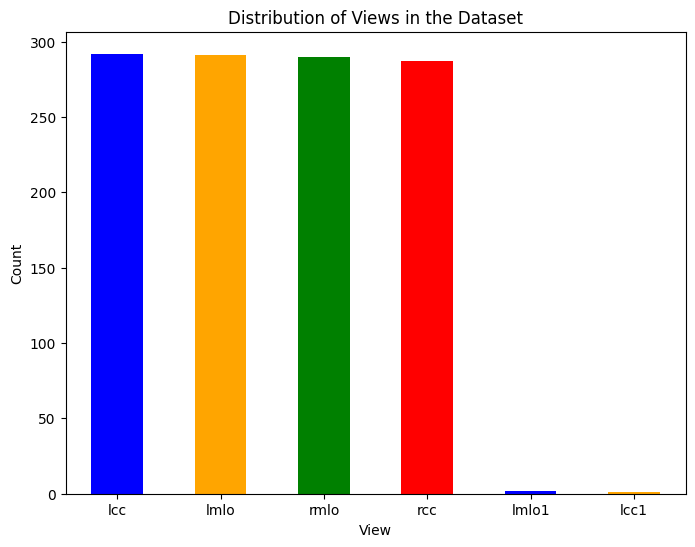

In [87]:
view_counts = data['View'].value_counts()
print(view_counts)

plt.figure(figsize=(8, 6))
view_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title('Distribution of Views in the Dataset')
plt.xlabel('View')
plt.ylabel('Count')
plt.xticks(ticks=range(len(view_counts.index)), labels=view_counts.index, rotation=0)
plt.show()

ClassCode
0    928
1    160
2     38
3     37
Name: count, dtype: int64


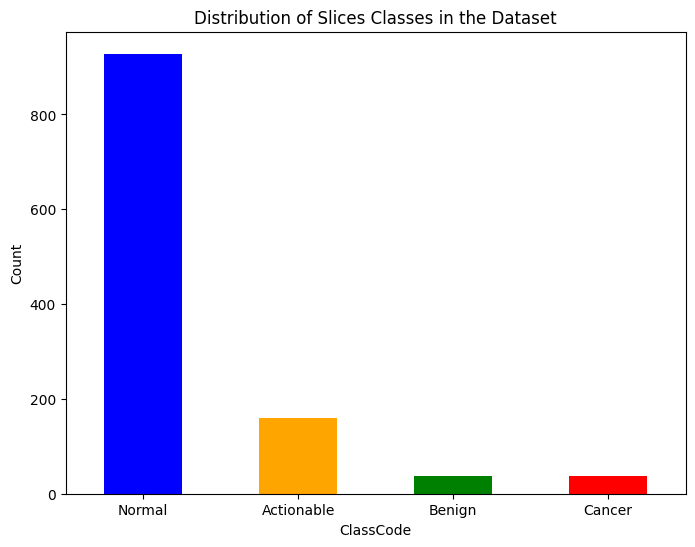

In [88]:
class_map = {'Normal': 0, 'Actionable': 1, 'Benign': 2, 'Cancer': 3}
class_cols = ['Normal', 'Actionable', 'Benign', 'Cancer']
data['ClassCode'] = data[class_cols].idxmax(axis=1).map(class_map)
class_counts = data['ClassCode'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title('Distribution of Slices Classes in the Dataset')
plt.xlabel('ClassCode')
plt.ylabel('Count')
plt.xticks(ticks=range(len(class_map)), labels=class_map.keys(), rotation=0)
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   PatientID     75 non-null     str  
 1   StudyUID      75 non-null     str  
 2   View          75 non-null     str  
 3   Subject       75 non-null     int64
 4   Slice         75 non-null     int64
 5   X             75 non-null     int64
 6   Y             75 non-null     int64
 7   Width         75 non-null     int64
 8   Height        75 non-null     int64
 9   Class         75 non-null     str  
 10  AD            75 non-null     int64
 11  VolumeSlices  75 non-null     int64
dtypes: int64(8), str(4)
memory usage: 7.2 KB


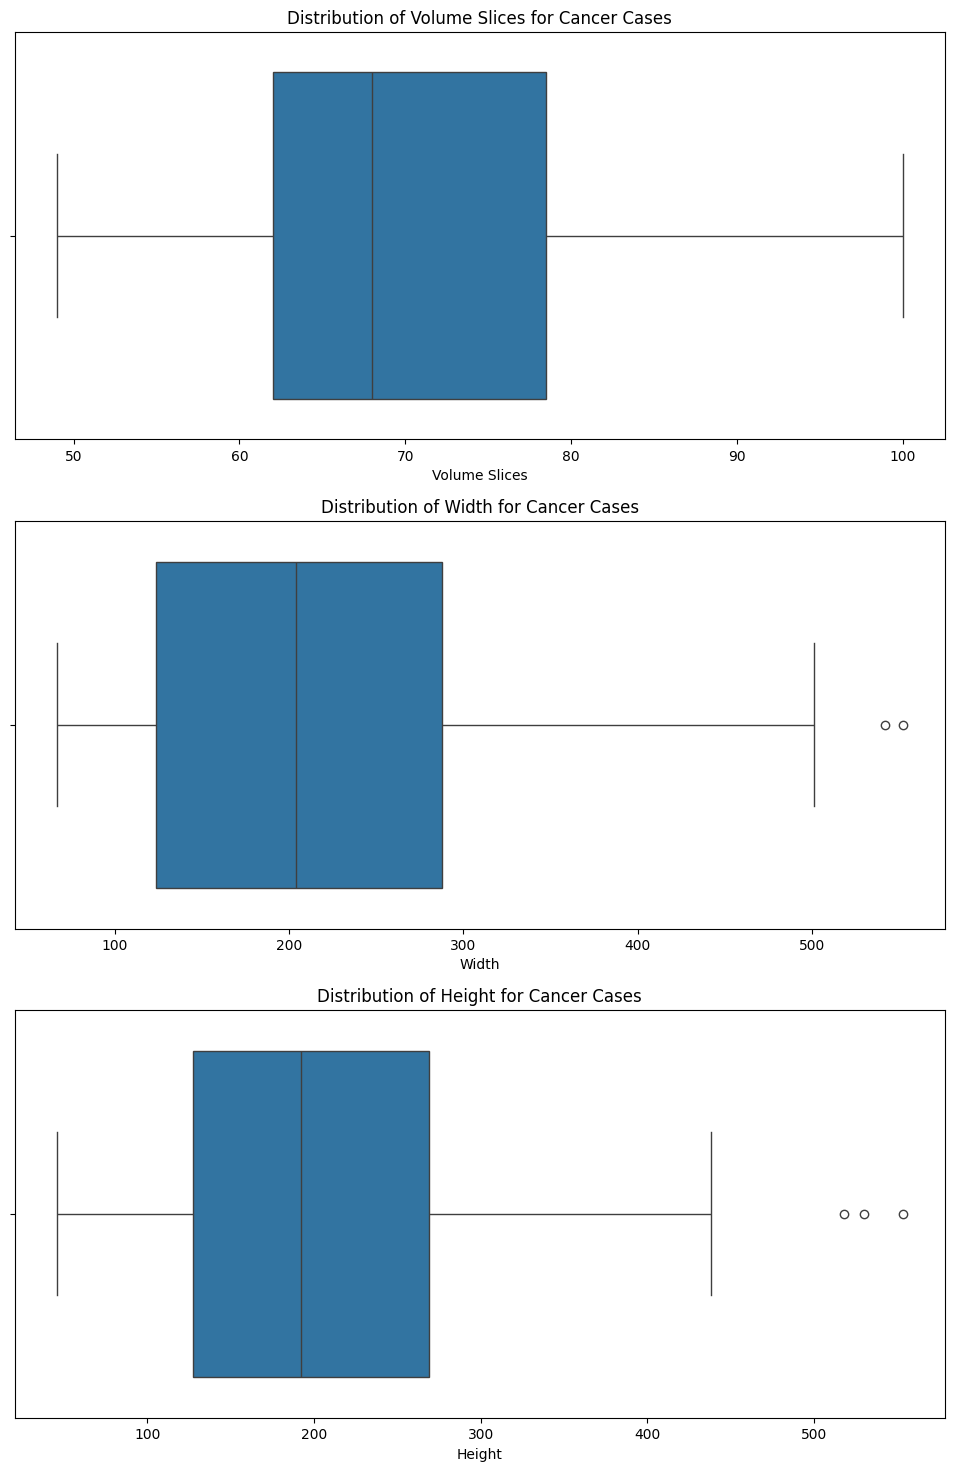

<Figure size 800x600 with 0 Axes>

In [96]:
import seaborn as sns

boxes = pd.read_csv(r'C:\Repositories\picard-anomalydetection\data\BCS-DBT-boxes-validation-v2-PHASE-2-Jan-2024.csv')
boxes.info()

anomaly_data = boxes[boxes['Class'].isin(['cancer', 'benign'])]


fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.figure(figsize=(8, 6))
sns.boxplot(x=anomaly_data['VolumeSlices'], ax=axes[0])
axes[0].set_title('Distribution of Volume Slices for Cancer Cases')
axes[0].set_xlabel('Volume Slices')

sns.boxplot(x=anomaly_data['Width'], ax=axes[1])
axes[1].set_title('Distribution of Width for Cancer Cases')
axes[1].set_xlabel('Width')

sns.boxplot(x=anomaly_data['Height'], ax=axes[2])
axes[2].set_title('Distribution of Height for Cancer Cases')
axes[2].set_xlabel('Height')


plt.tight_layout()
plt.show()


In [ ]:
benign = anomaly_data[anomaly_data['Class'] == 'benign']
cancer = anomaly_data[anomaly_data['Class'] == 'cancer']

benign['Area'] = benign['Width'] * benign['Height']
cancer['Area'] = cancer['Width'] * cancer['Height']

benign_area_mean = benign['Area'].mean()
cancer_area_mean = cancer['Area'].mean()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Area', data=anomaly_data)


Average area of benign anomalies: 66394.39
